HEART ATTACK PREDICTION


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
data=pd.read_csv('heart.csv')
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
data.shape

(918, 12)

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [4]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

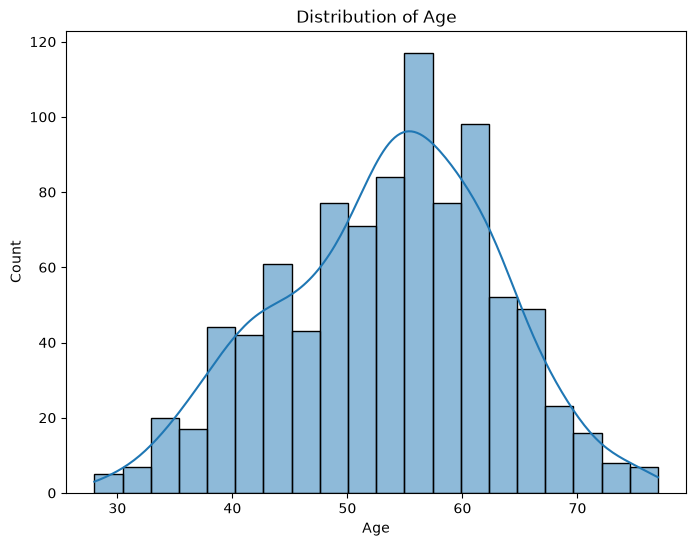

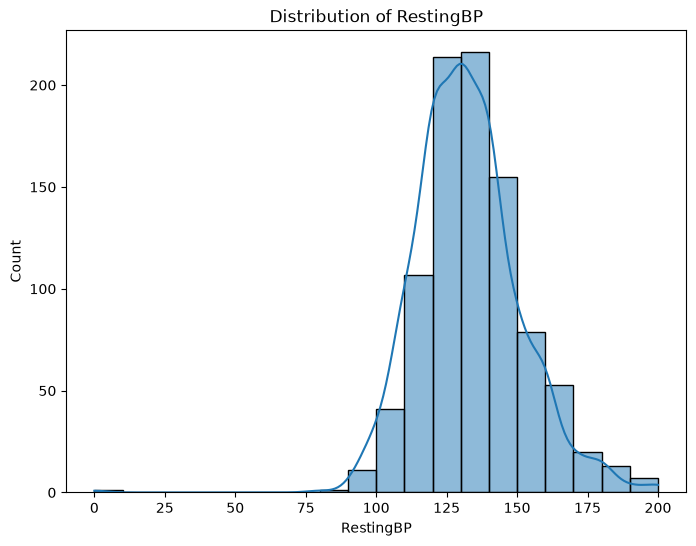

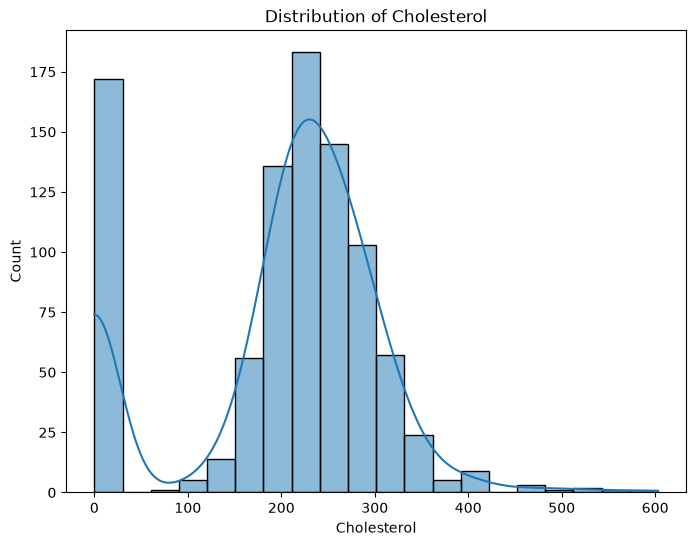

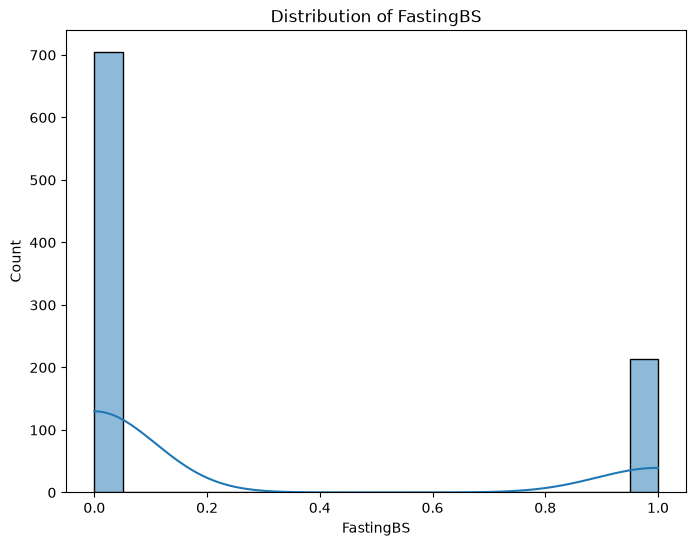

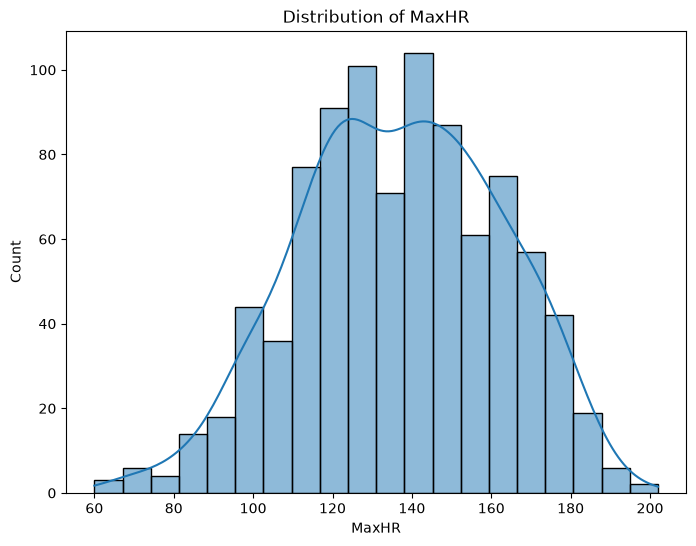

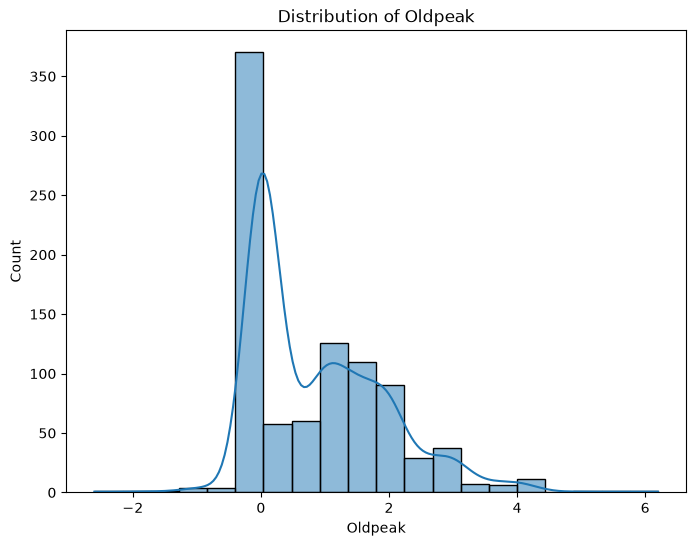

In [6]:
numeric_columns=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']
for col in numeric_columns:
    plt.figure(figsize=(8,6))
    sns.histplot(data[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.show()

In [7]:
data.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

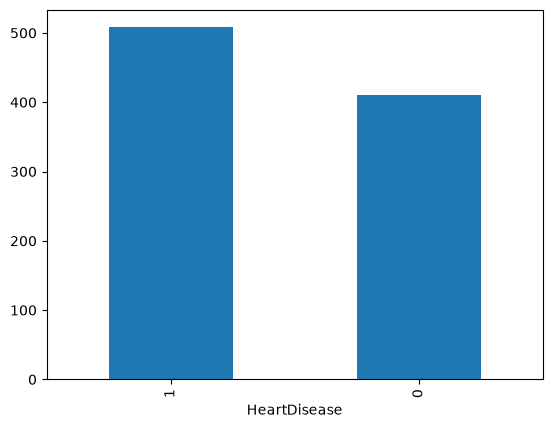

In [8]:
data['HeartDisease'].value_counts().plot(kind="bar")
#heart disease equally distributed

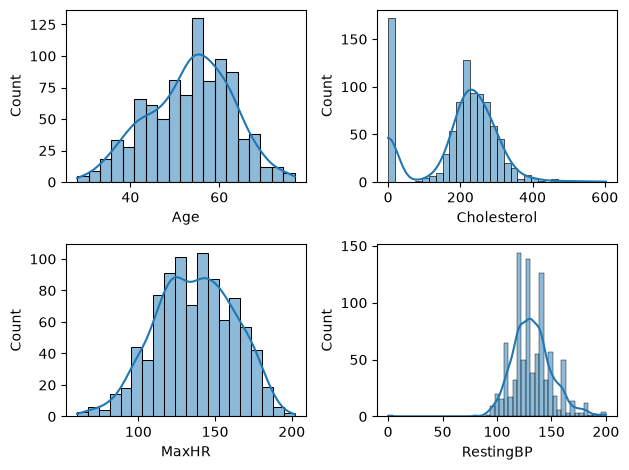

In [9]:
def distiplot(var,num):
    plt.subplot(2,2,num)
    sns.histplot(data[var],kde=True)
distiplot('Age',1)    
distiplot('Cholesterol',2)
distiplot('MaxHR',3) 
distiplot('RestingBP',4)
plt.tight_layout() 

In [10]:
#here resting bp distribution is unusual and shows one member with 0 bp which is impossible 
#and the data is false
#and here cholestrol it shows more than 150 members wuth 0 cholerstrol which is also a false value so we clean by taking mean value
ch_mean=data.loc[data['Cholesterol']!=0,'Cholesterol'].mean()
ch_mean
ch_mean.round(2)
data['Cholesterol']=data['Cholesterol'].replace(0,ch_mean)
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [11]:
bp_mean=data.loc[data['RestingBP']!=0,'RestingBP'].mean()
bp_mean
bp_mean.round(2)
data['RestingBP']=data['RestingBP'].replace(0,bp_mean)
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


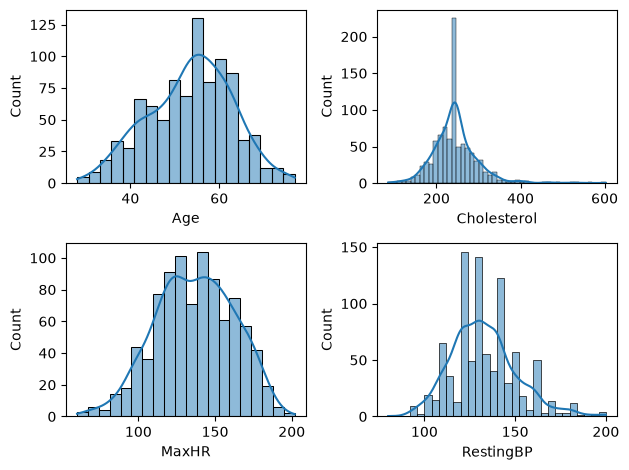

In [12]:
def distiplot(var,num):
    plt.subplot(2,2,num)
    sns.histplot(data[var],kde=True)
distiplot('Age',1)    
distiplot('Cholesterol',2)
distiplot('MaxHR',3) 
distiplot('RestingBP',4)
plt.tight_layout() 

In [13]:
pip install sheryanalysis==0.1.0

Note: you may need to restart the kernel to use updated packages.


In [14]:
import sheryanalysis as sh
sh.analyze(data)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': <StringDtype(storage='python', na_value=nan)>,
  'ChestPainType': <StringDtype(storage='python', na_value=nan)>,
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': <StringDtype(storage='python', na_value=nan)>,
  'MaxHR': dtype('int64'),
  'ExerciseAngina': <StringDtype(storage='python', na_value=nan)>,
  'Oldpeak': dtype('float64'),
  'ST_Slope': <StringDtype(storage='python', na_value=nan)>,
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'c

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


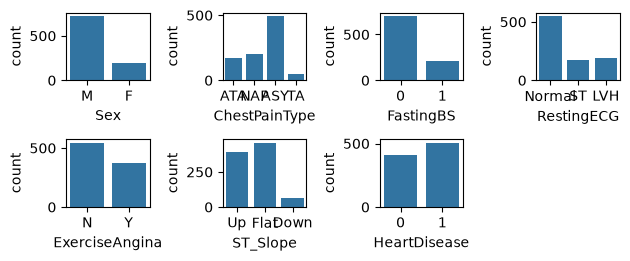

In [15]:
def catplot(var,num):
    plt.subplot(4,4,num)
    sns.countplot(x=data[var])
catplot('Sex',1)
catplot("ChestPainType",2)
catplot('FastingBS',3)
catplot('RestingECG',4)
catplot('ExerciseAngina',5)
catplot('ST_Slope',6)
catplot('HeartDisease',7)
plt.tight_layout()
data.head()







<Axes: xlabel='ChestPainType', ylabel='count'>

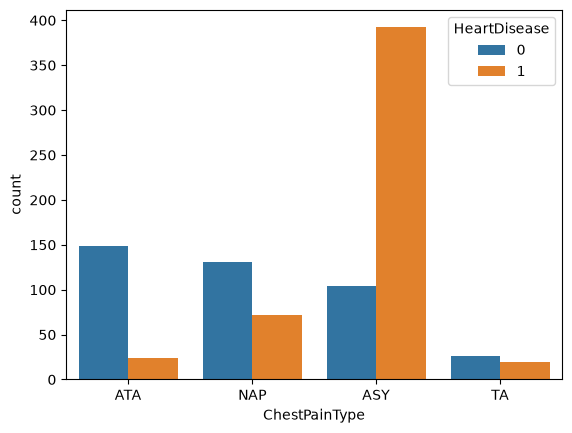

In [16]:
sns.countplot(x=data['ChestPainType'],hue=data['HeartDisease'])

<Axes: xlabel='Sex', ylabel='count'>

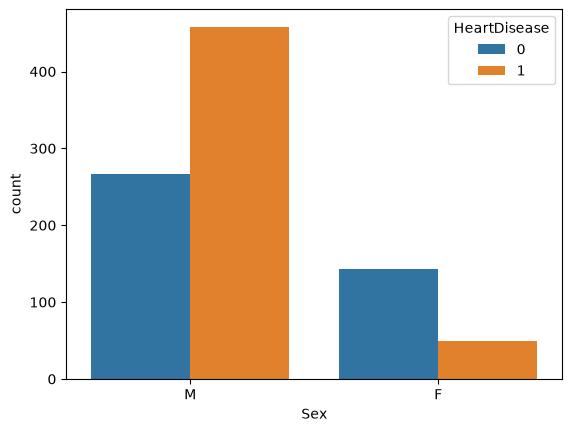

In [17]:
sns.countplot(x=data['Sex'],hue=data['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

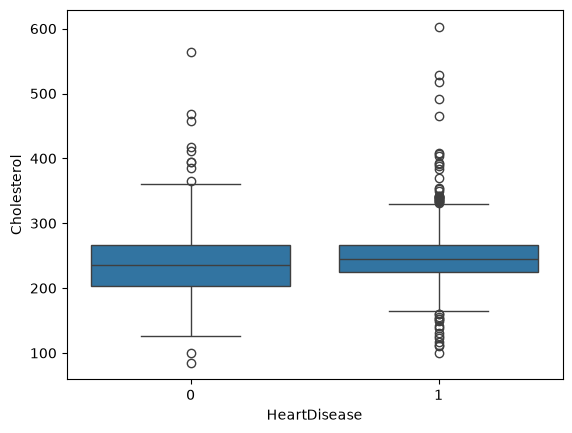

In [18]:
sns.boxplot(x='HeartDisease',y='Cholesterol',data=data)

<Axes: >

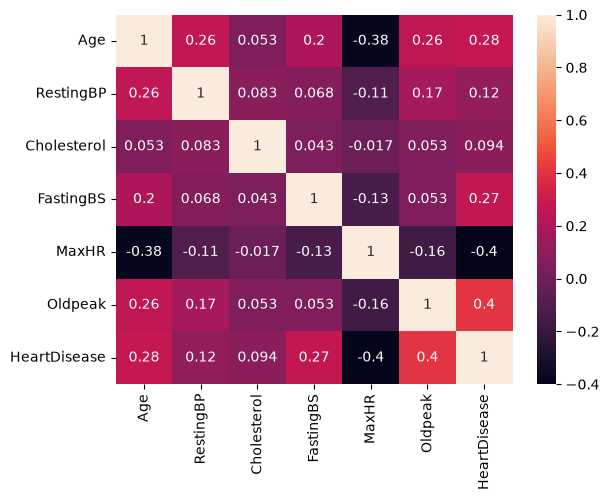

In [19]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

DATA PRE AND CLEANING


In [20]:
df_encode=pd.get_dummies(data,drop_first=True)

In [21]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [22]:
df_update=df_encode.astype(int)
df_update

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [23]:
from sklearn.preprocessing import StandardScaler
numeric_col=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler=StandardScaler()
df_encode[numeric_col]=scaler.fit_transform(df_encode[numeric_col])
df_encode.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832529,0,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.527192,-1.212922,0,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.141317,0.719935,0,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.303619,-0.574892,0,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.971022,-0.931438,0,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True


In [24]:
type_ch=['Sex_M','ChestPainType_ATA','ChestPainType_NAP','ChestPainType_TA','RestingECG_Normal','RestingECG_ST','ExerciseAngina_Y','ST_Slope_Flat','ST_Slope_Up']
for col in type_ch:
    df_encode[type_ch]=df_encode[type_ch].astype(int)
df_encode    


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832529,0,1.382928,-0.832432,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212922,0,0.754157,0.105664,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719935,0,-1.525138,-0.832432,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303619,-0.574892,0,-1.132156,0.574711,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971022,-0.931438,0,-0.581981,-0.832432,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253656,0.363389,0,-0.188999,0.293283,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637320,-0.968969,1,0.164684,2.357094,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141317,-2.132437,0,-0.857069,0.293283,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141317,-0.162048,0,1.461525,-0.832432,1,0,1,0,0,0,0,0,1,0


In [25]:
df_encode['Sex_M']=df_encode['Sex_M'].astype(int)

In [26]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832529,0,1.382928,-0.832432,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212922,0,0.754157,0.105664,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719935,0,-1.525138,-0.832432,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303619,-0.574892,0,-1.132156,0.574711,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971022,-0.931438,0,-0.581981,-0.832432,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253656,0.363389,0,-0.188999,0.293283,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637320,-0.968969,1,0.164684,2.357094,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141317,-2.132437,0,-0.857069,0.293283,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141317,-0.162048,0,1.461525,-0.832432,1,0,1,0,0,0,0,0,1,0


In [27]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832529,0,1.382928,-0.832432,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212922,0,0.754157,0.105664,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719935,0,-1.525138,-0.832432,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303619,-0.574892,0,-1.132156,0.574711,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971022,-0.931438,0,-0.581981,-0.832432,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253656,0.363389,0,-0.188999,0.293283,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637320,-0.968969,1,0.164684,2.357094,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141317,-2.132437,0,-0.857069,0.293283,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141317,-0.162048,0,1.461525,-0.832432,1,0,1,0,0,0,0,0,1,0


In [28]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832529,0,1.382928,-0.832432,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212922,0,0.754157,0.105664,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719935,0,-1.525138,-0.832432,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303619,-0.574892,0,-1.132156,0.574711,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971022,-0.931438,0,-0.581981,-0.832432,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253656,0.363389,0,-0.188999,0.293283,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637320,-0.968969,1,0.164684,2.357094,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141317,-2.132437,0,-0.857069,0.293283,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141317,-0.162048,0,1.461525,-0.832432,1,0,1,0,0,0,0,0,1,0


In [29]:
final_dt=df_encode

In [30]:
from scipy.stats import pearsonr
selected_features=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','Sex_M','ChestPainType_ATA','ChestPainType_NAP','ChestPainType_TA','RestingECG_Normal','RestingECG_ST','ExerciseAngina_Y','ST_Slope_Flat','ST_Slope_Up']
correlations={
    feature:pearsonr(df_encode[feature],df_encode['HeartDisease'])[0]
    for feature in selected_features
}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['feature','Pearson_correlation'])
correlation_df.sort_values(by='Pearson_correlation',ascending=False)

,feature,Pearson_correlation
13,ST_Slope_Flat,0.554134
12,ExerciseAngina_Y,0.494282
5,Oldpeak,0.403951
6,Sex_M,0.305445
0,Age,0.282039
3,FastingBS,0.267291
1,RestingBP,0.117938
11,RestingECG_ST,0.102527
2,Cholesterol,0.094071
9,ChestPainType_TA,-0.054790


In [31]:
import sheryanalysis as sa
sa.analyze(df_encode)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 16)
🧱 Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

✅ No null values found

🔠 Categorical Columns: ['FastingBS', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 16),
 'columns': ['Age',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'MaxHR',
  'Oldpeak',
  'HeartDisease',
  'Sex_M',
  'ChestPainType_ATA',
  'ChestPainType_NAP',
  'ChestPainType_TA',
  'RestingECG_Normal',
  'RestingECG_ST',
  'ExerciseAngina_Y',
  'ST_Slope_Flat',
  'ST_Slope_Up'],
 'dtypes': {'Age': dtype('float64'),
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'MaxHR': dtype('float64'),
  'Oldpeak': dtype('float64'),
  'HeartDisease': dtype('int64'),
  'Sex_M': dtype('int64'),
  'ChestPainType_ATA': dtype('int64'),
  'ChestPainType_NAP': dtype('int64'),
  'ChestPainType_TA': dtype('int64'),
  'RestingECG_Normal': dtype('int64'),
  'RestingECG_ST': dtype('int64'),
  'ExerciseAngina_Y': dtype('int64'),
  'ST_Slope_Flat': dtype('int64'),
  'ST_Slope_Up': dtype('int64')},
 'null_counts': {'Age': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'MaxHR': 0,
  'Oldpeak': 0,
  'HeartDisease': 0,
  

In [32]:
cat_features=['FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


from scipy.stats import chi2_contingency
import pandas as pd
alpha=0.05
chi2_results={}
for col in cat_features:
    contigency=pd.crosstab(df_encode[col],df_encode['HeartDisease'])
    chi2_stat,p_val,_,_=chi2_contingency(contigency)
    decision='Reject Null (Keep Feature)' if p_val<alpha else 'Accept Null (Drop Feature)'
    chi2_results[col]={
        'chi2_statistics':chi2_stat,
        'p_value':p_val,
        'Decision':decision
    }
chi2_df=pd.DataFrame(chi2_results).T
chi2_df=chi2_df.sort_values(by='p_value')
chi2_df    

,chi2_statistics,p_value,Decision
ST_Slope_Up,352.823905,0.0,Reject Null (Keep Feature)
ST_Slope_Flat,279.659914,0.0,Reject Null (Keep Feature)
ExerciseAngina_Y,222.259383,0.0,Reject Null (Keep Feature)
ChestPainType_ATA,146.236323,0.0,Reject Null (Keep Feature)
Sex_M,84.145101,0.0,Reject Null (Keep Feature)
FastingBS,64.320679,0.0,Reject Null (Keep Feature)
ChestPainType_NAP,40.608711,0.0,Reject Null (Keep Feature)
RestingECG_ST,9.135266,0.002507,Reject Null (Keep Feature)
RestingECG_Normal,7.327532,0.006791,Reject Null (Keep Feature)
ChestPainType_TA,2.273802,0.131577,Accept Null (Drop Feature)


In [33]:
final_dt=df_encode[['Sex_M','FastingBS','Age','ST_Slope_Up','ST_Slope_Flat','ExerciseAngina_Y','RestingBP','Oldpeak','RestingECG_ST','HeartDisease']]
final_dt

,Sex_M,FastingBS,Age,ST_Slope_Up,ST_Slope_Flat,ExerciseAngina_Y,RestingBP,Oldpeak,RestingECG_ST,HeartDisease
0,1,0,-1.433140,1,0,0,0.414853,-0.832432,0,0
1,0,0,-0.478484,0,1,0,1.527192,0.105664,0,1
2,1,0,-1.751359,1,0,0,-0.141317,-0.832432,1,0
3,0,0,-0.584556,0,1,1,0.303619,0.574711,0,1
4,1,0,0.051881,1,0,0,0.971022,-0.832432,0,0
...,...,...,...,...,...,...,...,...,...,...
913,1,0,-0.902775,0,1,0,-1.253656,0.293283,0,1
914,1,1,1.536902,0,1,0,0.637320,2.357094,0,1
915,1,0,0.370100,0,1,1,-0.141317,0.293283,0,1
916,0,0,0.370100,0,1,0,-0.141317,-0.832432,0,1


<Axes: >

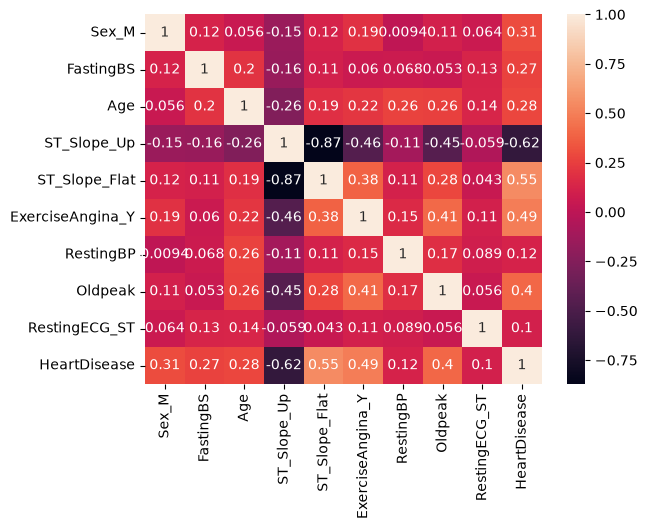

In [34]:
sns.heatmap(final_dt.corr(numeric_only=True),annot=True)

MODELS

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score

In [41]:
X=final_dt.drop('HeartDisease',axis=1)
y=final_dt['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)
models={
    'LOGISTICREGRESSION':LogisticRegression(),
    'KNN':KNeighborsClassifier(n_neighbors=5),
    'NAIVEBYES':GaussianNB(),
    'SVM':SVC(kernel='rbf'),
    'DECISIONTREE':DecisionTreeClassifier()


}
result=[]
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_predict=model.predict(X_test_scaled)
    acc=accuracy_score(y_test,y_predict)
    f1=f1_score(y_test,y_predict)
    mattrix=confusion_matrix(y_test,y_predict)
    result.append({
        'model':name,
        'accuracy':round(acc,4),
        'f1':round(f1,4),
        'confusionmatrix':mattrix

    })
    


In [42]:
result

[{'model': 'LOGISTICREGRESSION',
  'accuracy': 0.8424,
  'f1': 0.8612,
  'confusionmatrix': array([[65, 12],
         [17, 90]])},
 {'model': 'KNN',
  'accuracy': 0.8152,
  'f1': 0.8365,
  'confusionmatrix': array([[63, 14],
         [20, 87]])},
 {'model': 'NAIVEBYES',
  'accuracy': 0.837,
  'f1': 0.8544,
  'confusionmatrix': array([[66, 11],
         [19, 88]])},
 {'model': 'SVM',
  'accuracy': 0.8315,
  'f1': 0.8558,
  'confusionmatrix': array([[61, 16],
         [15, 92]])},
 {'model': 'DECISIONTREE',
  'accuracy': 0.7772,
  'f1': 0.8057,
  'confusionmatrix': array([[58, 19],
         [22, 85]])}]

In [43]:
# saving our model as pickle file
import joblib
joblib.dump(models['LOGISTICREGRESSION'],'logist_heartdis.pkl')
joblib.dump(scaler,'scalerlo.pkl')
joblib.dump(X.columns.to_list(),'coloflo.pkl')

['coloflo.pkl']